# Thermal Management Replication (V3.2 — Multi-Zone Analysis)
**Final Year Mega Project — Dedicated Thermal Safety Validation**

This notebook is a standalone, focused replication of the **Thermal Management** pillar (Section 3.3) of the SLR paper. It validates that AI-based anomaly detection and classification models can identify dangerous battery thermal events from real-world Magenta Mobility fleet data.

### Key Innovations in V3.2:
1. **Balanced Data:** Alert Logs downsampled to 50/50 Critical vs Benign to eliminate class-imbalance artifacts.
2. **Multi-Zone Thermal Mapping:** Isolation Forest now monitors Battery Temp (`vbt`), Controller Temp (`vct`), AND Motor Temp (`vmt`) simultaneously — catching cross-zone failures.
3. **Paper-Referenced Models:** SVM Classifier modeled after BattBee [Ref 13] from the SLR.

### 5 Thermal Models (Progression):
| Rank | Model | Paper Reference |
|------|-------|----------------|
| 5 (worst) | Rule-Based Threshold | Sec 3.3 — passive shutdowns |
| 4 | Logistic Regression | Sec 5.1 — linear baseline |
| 3 | SVM Classifier | BattBee [Ref 13] |
| 2 | Isolation Forest (Multi-Zone) | Sec 3.3.2 — unsupervised |
| 1 (best) | Random Forest (200 trees) | Sec 3.3.2 — ensemble ML |

In [1]:
!pip install -q ijson plotly matplotlib seaborn scikit-learn pandas pyarrow fastparquet openpyxl psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import time
import psutil
import warnings
import random
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import zipfile
from google.colab import drive
import ijson

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def check_ram():
    process = psutil.Process(os.getpid())
    ram_used = process.memory_info().rss / (1024 ** 3)
    print(f"RAM Used: {ram_used:.2f} GB")

check_ram()

RAM Used: 0.27 GB


In [3]:
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/FYP_Battery_Project'
MDL_DIR = os.path.join(DRIVE_DIR, 'Models_v3_2_Thermal')
os.makedirs(MDL_DIR, exist_ok=True)

zip_path = os.path.join(DRIVE_DIR, 'Data.zip')
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    print("Unzipping data...")
    start_t = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Unzipped in {time.time() - start_t:.2f}s")
else:
    print(f"ERROR: {zip_path} not found!")

Mounted at /content/drive
Unzipping data...
Unzipped in 9.56s


## 2. Loading All Thermal Data Sources

### Source 1: Alert Logs (Supervised Labels)
Fleet alert events with `Alert Type`, `Battery Temp`, `SoC`, `Voltage`, `Speed`.

### Source 2: OEM Telemetry (Multi-Zone Temperatures)
Euler HiLoad fleet with **3 thermal zones**: Battery (`vbt`), Controller (`vct`), Motor (`vmt`).

### Source 3: Trip Reports (Thermal Stress Context)
Per-trip energy consumption and SoC drain patterns.

In [4]:
# ===== SOURCE 1: Alert Logs =====
alert_files = glob.glob(os.path.join(extract_path, '**', 'Alert Log*.xlsx'), recursive=True)
print(f"Found {len(alert_files)} Alert Log files")

df_alerts = pd.DataFrame()
for af in alert_files:
    try:
        tmp = pd.read_excel(af, engine='openpyxl')
        df_alerts = pd.concat([df_alerts, tmp], ignore_index=True)
        print(f"  Loaded {len(tmp)} rows from {os.path.basename(af)}")
    except Exception as e:
        print(f"  Error: {e}")

print(f"\nTotal Alert Records: {len(df_alerts)}")
print(f"Alert Types found: {df_alerts['Alert Type'].unique().tolist()}")
print(f"Columns: {df_alerts.columns.tolist()}")

Found 2 Alert Log files
  Loaded 170353 rows from Alert Log12-FEB-2026_11_47_07.xlsx
  Loaded 50837 rows from Alert Log12-FEB-2026_11_47_03.xlsx

Total Alert Records: 221190
Alert Types found: ['Harsh Braking', 'Deep Discharge Warning', 'Low SoC', 'Harsh Acceleration', 'Harsh Cornering', 'OverSpeed', 'Battery Under Voltage', 'Aux. Battery Under Voltage', 'Consecutive Fast Charging']
Columns: ['S.No.', 'Vehicle No.', 'New Vehicle No.', 'OEM & Model', 'Date & Time', 'Alert Type', 'Speed (kmph)', 'SoC (% )', 'Batt. Volt. (V)', 'Batt. Temp.(°c)', 'GPS', 'Aux. Batt. Under Volt. (V)']


In [5]:
# ===== SOURCE 2: OEM Telemetry (Multi-Zone) =====
# Try to reuse existing Parquet from V2/V3
oem_parquet = None
for vdir in ['Data_v3', 'Data_v2']:
    candidate = os.path.join(DRIVE_DIR, vdir, f'oem_sampled_{vdir[-2:]}.parquet')
    if os.path.exists(candidate):
        oem_parquet = candidate
        break

if oem_parquet:
    print(f"Reusing existing Parquet: {os.path.basename(oem_parquet)}")
    df_oem = pd.read_parquet(oem_parquet)
else:
    print("No existing Parquet found. Sampling from raw JSON...")
    oem_search = glob.glob(os.path.join(extract_path, '**', 'tms_history_l2_oem.json'), recursive=True)
    if oem_search:
        oem_json = oem_search[0]
        # Quick reservoir sample (500K is enough for thermal)
        sampled = []
        total = 0
        oem_keys = ['cn', 'oem', 'mdl', 'dts', 'soh', 'soc', 'vbv', 'vbc', 'vbt', 'vct', 'vmt', 'csp', 'od']
        with open(oem_json, 'rb') as f:
            for obj in ijson.items(f, 'item'):
                filtered = {k: obj[k] for k in oem_keys if k in obj}
                for k, v in list(filtered.items()):
                    if isinstance(v, dict) and '$date' in v:
                        filtered[k] = v['$date']
                if total < 500000:
                    sampled.append(filtered)
                else:
                    j = random.randint(0, total)
                    if j < 500000:
                        sampled[j] = filtered
                total += 1
                if total % 1000000 == 0:
                    print(f"  Processed {total/1e6:.1f}M...")
        df_oem = pd.DataFrame(sampled)
        for col in ['soh', 'soc', 'vbv', 'vbc', 'vbt', 'vct', 'vmt', 'csp', 'od']:
            if col in df_oem.columns:
                df_oem[col] = pd.to_numeric(df_oem[col], errors='coerce')
        print(f"Sampled {len(df_oem)} OEM records")

print(f"OEM shape: {df_oem.shape}")

# Check thermal zone availability
for col in ['vbt', 'vct', 'vmt']:
    if col in df_oem.columns:
        valid = df_oem[col].notna().sum()
        rng = f"{df_oem[col].min():.1f} - {df_oem[col].max():.1f}" if valid > 0 else "N/A"
        print(f"  {col}: {valid} valid values, range: {rng}")
    else:
        print(f"  {col}: COLUMN MISSING")

check_ram()

Reusing existing Parquet: oem_sampled_v3.parquet
OEM shape: (395677, 13)
  vbt: 395677 valid values, range: 0.0 - 44.0
  vct: 395677 valid values, range: 10.0 - 67.0
  vmt: 395676 valid values, range: 10.0 - 138.0
RAM Used: 0.50 GB


In [6]:
# ===== SOURCE 3: Trip Reports =====
trip_files = glob.glob(os.path.join(extract_path, '**', 'Trip Report*.xlsx'), recursive=True)
print(f"Found {len(trip_files)} Trip Report files")

df_trips = pd.DataFrame()
for tf in trip_files:
    try:
        tmp = pd.read_excel(tf, engine='openpyxl')
        df_trips = pd.concat([df_trips, tmp], ignore_index=True)
        print(f"  Loaded {len(tmp)} rows from {os.path.basename(tf)}")
    except Exception as e:
        print(f"  Error: {e}")

print(f"Total Trip Records: {len(df_trips)}")
check_ram()

Found 3 Trip Report files
  Loaded 47122 rows from Trip Report Log12-FEB-2026_11_25_29.xlsx
  Loaded 17466 rows from Trip Report Log12-FEB-2026_11_25_21.xlsx
  Loaded 48037 rows from Trip Report Log12-FEB-2026_11_25_15.xlsx
Total Trip Records: 112625
RAM Used: 0.58 GB


## 3. Thermal Exploratory Data Analysis

### 3.1 Alert Type Distribution (The Imbalance Problem)
Before balancing, we visualize the raw class distribution to show WHY downsampling is needed.

### 3.2 Multi-Zone Temperature Distributions
Battery, Controller, and Motor temperature profiles from the Euler fleet.

### 3.3 Trip-Level Thermal Stress
Energy consumed vs SoC drain — higher energy = more thermal stress.

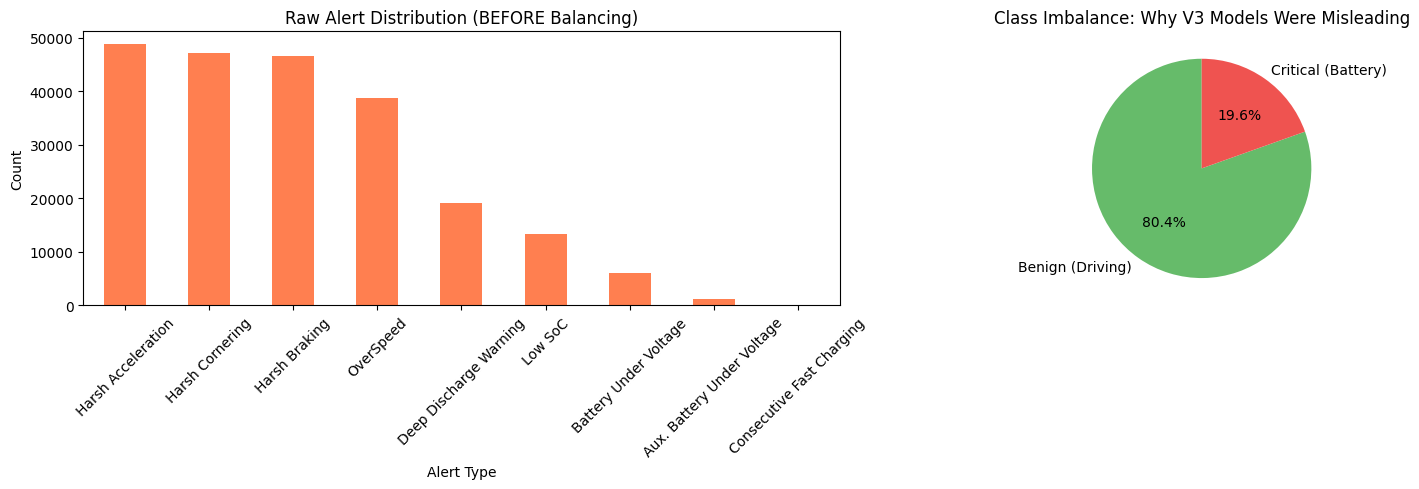

Critical alerts: 32588, Benign alerts: 134056
Imbalance ratio: 1:4


In [7]:
# 3.1 Alert Type Distribution - BEFORE balancing
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw distribution
alert_counts = df_alerts['Alert Type'].value_counts()
alert_counts.plot(kind='bar', color='coral', ax=axes[0])
axes[0].set_title("Raw Alert Distribution (BEFORE Balancing)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Critical vs Benign pie
critical_types = ['Deep Discharge Warning', 'Low SoC']
benign_types = ['Harsh Acceleration', 'Harsh Braking', 'OverSpeed']
known = df_alerts[df_alerts['Alert Type'].isin(critical_types + benign_types)]
crit_count = known[known['Alert Type'].isin(critical_types)].shape[0]
ben_count = known[known['Alert Type'].isin(benign_types)].shape[0]
axes[1].pie([ben_count, crit_count], labels=['Benign (Driving)', 'Critical (Battery)'],
            autopct='%1.1f%%', colors=['#66bb6a', '#ef5350'], startangle=90)
axes[1].set_title("Class Imbalance: Why V3 Models Were Misleading")

plt.tight_layout()
plt.show()
print(f"Critical alerts: {crit_count}, Benign alerts: {ben_count}")
print(f"Imbalance ratio: 1:{ben_count//max(crit_count,1)}")

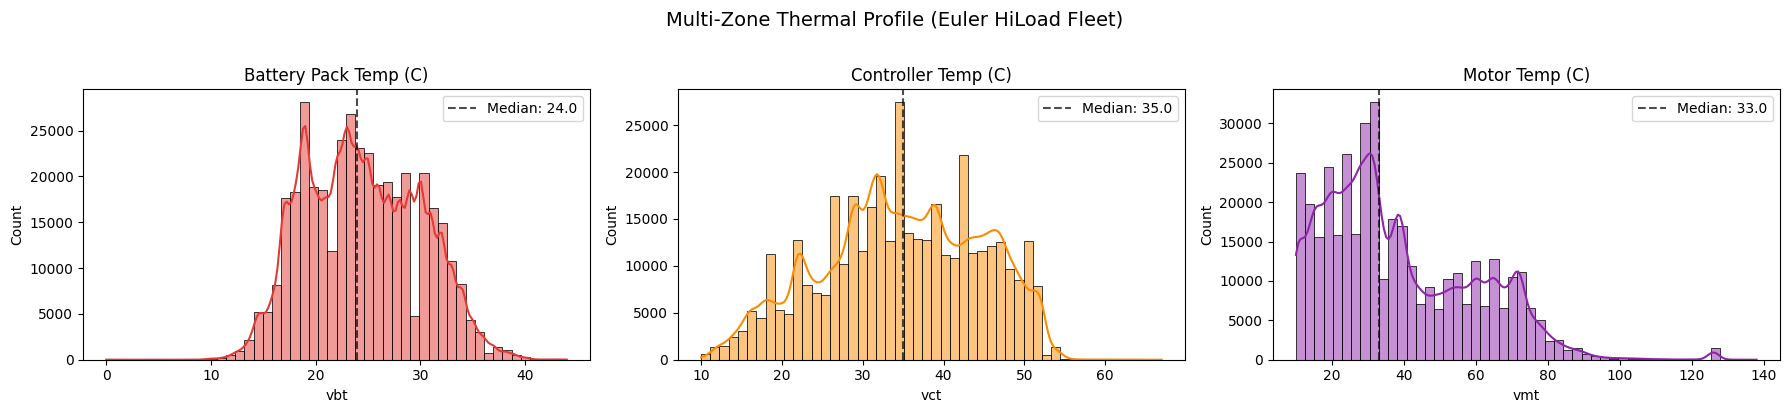

In [8]:
# 3.2 Multi-Zone Temperature Distributions
euler_fleet = df_oem[df_oem['oem'].str.lower() == 'euler'].copy()
temp_cols = [c for c in ['vbt', 'vct', 'vmt'] if c in euler_fleet.columns and euler_fleet[c].notna().sum() > 100]

if len(temp_cols) > 0:
    fig, axes = plt.subplots(1, len(temp_cols), figsize=(6 * len(temp_cols), 4))
    if len(temp_cols) == 1:
        axes = [axes]

    labels = {'vbt': 'Battery Pack Temp (C)', 'vct': 'Controller Temp (C)', 'vmt': 'Motor Temp (C)'}
    colors = {'vbt': '#e53935', 'vct': '#fb8c00', 'vmt': '#8e24aa'}

    for ax, col in zip(axes, temp_cols):
        data = euler_fleet[col].dropna()
        sns.histplot(data, bins=50, kde=True, color=colors.get(col, 'steelblue'), ax=ax)
        ax.set_title(labels.get(col, col))
        ax.axvline(data.median(), color='black', linestyle='--', alpha=0.7, label=f'Median: {data.median():.1f}')
        ax.legend()

    plt.suptitle("Multi-Zone Thermal Profile (Euler HiLoad Fleet)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No thermal zone columns available for plotting.")

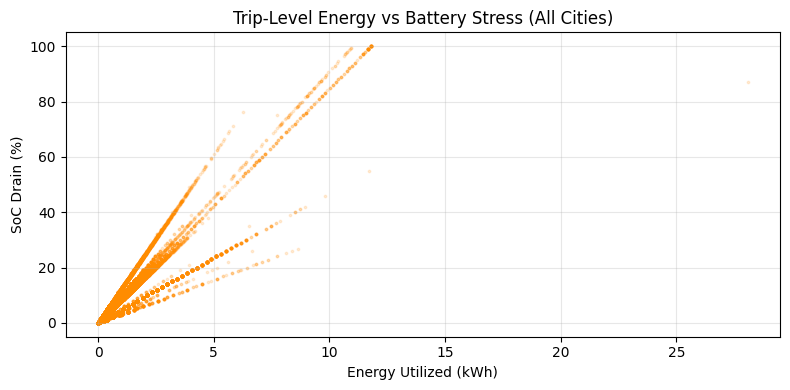

In [9]:
# 3.3 Trip-Level Thermal Stress
if len(df_trips) > 0:
    soc_col = [c for c in df_trips.columns if 'SoC Drain' in c]
    energy_col = [c for c in df_trips.columns if 'Energy' in c]

    if soc_col and energy_col:
        trip_clean = df_trips.dropna(subset=[soc_col[0], energy_col[0]]).copy()
        trip_clean[soc_col[0]] = pd.to_numeric(trip_clean[soc_col[0]], errors='coerce')
        trip_clean[energy_col[0]] = pd.to_numeric(trip_clean[energy_col[0]], errors='coerce')
        trip_clean = trip_clean.dropna(subset=[soc_col[0], energy_col[0]])

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.scatter(trip_clean[energy_col[0]], trip_clean[soc_col[0]], s=3, alpha=0.15, color='darkorange')
        ax.set_xlabel("Energy Utilized (kWh)")
        ax.set_ylabel("SoC Drain (%)")
        ax.set_title("Trip-Level Energy vs Battery Stress (All Cities)")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## 4. Balanced Thermal Classification Dataset

We apply **50/50 downsampling** to fix the class imbalance:
- Keep ALL critical alerts (Deep Discharge Warning, Low SoC)
- Randomly sample an **equal number** of benign alerts

This forces models to genuinely learn the V-I-T physics signatures that separate dangerous battery states from normal driving infractions.

In [10]:
# Define label mapping
critical_alerts = ['Deep Discharge Warning', 'Low SoC']
benign_alerts = ['Harsh Acceleration', 'Harsh Braking', 'OverSpeed']

# Filter to known types only
known_alerts = df_alerts[df_alerts['Alert Type'].isin(critical_alerts + benign_alerts)].copy()
known_alerts['label'] = known_alerts['Alert Type'].apply(lambda x: 1 if x in critical_alerts else 0)

# Identify feature columns (handle Excel naming with spaces)
soc_col = [c for c in known_alerts.columns if 'SoC' in c and '%' in c][0]
volt_col = [c for c in known_alerts.columns if 'Volt' in c and 'Aux' not in c][0]
speed_col = [c for c in known_alerts.columns if 'Speed' in c][0]
temp_col = [c for c in known_alerts.columns if 'Temp' in c][0]

print(f"Feature columns: {soc_col}, {volt_col}, {speed_col}, {temp_col}")

# Convert to numeric
for col in [soc_col, volt_col, speed_col]:
    known_alerts[col] = pd.to_numeric(known_alerts[col], errors='coerce')
known_alerts[temp_col] = pd.to_numeric(known_alerts[temp_col], errors='coerce')

# Build feature list (include temp only if enough valid data)
feat_cols = [soc_col, volt_col, speed_col]
temp_valid = known_alerts[temp_col].notna().sum()
print(f"Battery Temp valid entries: {temp_valid}")
if temp_valid > 500:
    feat_cols.append(temp_col)
    print("Including Battery Temp as feature.")
else:
    print("Battery Temp mostly missing. Using SoC, Volt, Speed only.")

# Drop rows with NaN in features
clean = known_alerts.dropna(subset=feat_cols + ['label']).copy()

# === 50/50 BALANCED DOWNSAMPLING ===
critical_df = clean[clean['label'] == 1]
benign_df = clean[clean['label'] == 0]

n_critical = len(critical_df)
n_sample = min(n_critical, len(benign_df))

# Downsample benign to match critical count
benign_sampled = benign_df.sample(n=n_sample, random_state=SEED)
balanced_df = pd.concat([critical_df, benign_sampled], ignore_index=True).sample(frac=1, random_state=SEED)

print(f"\n=== BALANCED DATASET ===")
print(f"Critical (1): {balanced_df['label'].sum()}")
print(f"Benign   (0): {(balanced_df['label'] == 0).sum()}")
print(f"Total:        {len(balanced_df)}")
print(f"Balance:      {balanced_df['label'].mean()*100:.1f}% critical")

# Train/Test Split (80/20, stratified)
X = balanced_df[feat_cols].values
y = balanced_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Feature columns: SoC (% ), Batt. Volt. (V), Speed (kmph), Batt. Temp.(°c)
Battery Temp valid entries: 19010
Including Battery Temp as feature.

=== BALANCED DATASET ===
Critical (1): 5157
Benign   (0): 5157
Total:        10314
Balance:      50.0% critical

Train: (8251, 4), Test: (2063, 4)


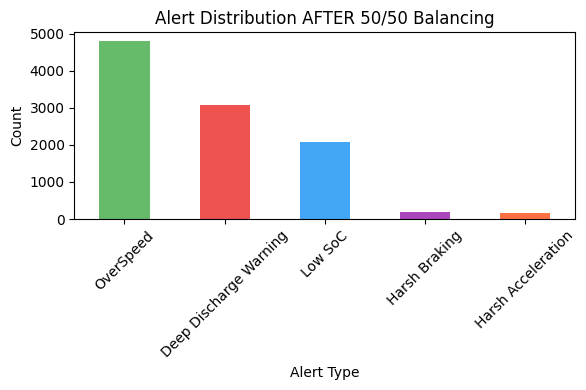

In [11]:
# Post-balancing distribution
fig, ax = plt.subplots(figsize=(6, 4))
balanced_df['Alert Type'].value_counts().plot(kind='bar', color=['#66bb6a', '#ef5350', '#42a5f5', '#ab47bc', '#ff7043'], ax=ax)
ax.set_title("Alert Distribution AFTER 50/50 Balancing")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Thermal Model 1 (Baseline): Rule-Based Threshold
**Paper Ref:** Section 3.3 — *"Traditional BMS: passive over-temperature shutdowns"*

A hand-crafted rule system with no machine learning. If `SoC < 15%` OR `Voltage < 48V` OR `Speed == 0 AND SoC < 10%`, flag as critical. This represents the pre-AI era of battery management.

In [12]:
soc_idx = feat_cols.index(soc_col)
volt_idx = feat_cols.index(volt_col)
speed_idx = feat_cols.index(speed_col)

def rule_based_predict(X_raw):
    preds = []
    for row in X_raw:
        soc = row[soc_idx]
        volt = row[volt_idx]
        speed = row[speed_idx]
        if soc < 15 or volt < 48 or (speed == 0 and soc < 10):
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)

# Use RAW (unscaled) test data for rule-based
rule_pred = rule_based_predict(X_test)
f1_rule = f1_score(y_test, rule_pred, average='weighted')
acc_rule = accuracy_score(y_test, rule_pred)
prec_rule = precision_score(y_test, rule_pred, average='weighted')
rec_rule = recall_score(y_test, rule_pred, average='weighted')

print(f"Rule-Based Threshold Results:")
print(f"  F1: {f1_rule:.4f} | Accuracy: {acc_rule:.4f} | Precision: {prec_rule:.4f} | Recall: {rec_rule:.4f}")
print()
print(classification_report(y_test, rule_pred, target_names=['Benign', 'Critical']))

Rule-Based Threshold Results:
  F1: 0.9363 | Accuracy: 0.9365 | Precision: 0.9420 | Recall: 0.9365

              precision    recall  f1-score   support

      Benign       0.89      0.99      0.94      1032
    Critical       0.99      0.88      0.93      1031

    accuracy                           0.94      2063
   macro avg       0.94      0.94      0.94      2063
weighted avg       0.94      0.94      0.94      2063



## 6. Thermal Model 2: Logistic Regression
**Paper Ref:** Section 5.1 — linear baseline comparison.

A linear decision boundary in V-I-T-Speed space. Will outperform rules but miss the non-linear thermal boundaries that separate subtle battery stress from driving infractions.

In [13]:
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_model.fit(X_train_s, y_train)

lr_pred = lr_model.predict(X_test_s)
f1_lr = f1_score(y_test, lr_pred, average='weighted')
acc_lr = accuracy_score(y_test, lr_pred)
prec_lr = precision_score(y_test, lr_pred, average='weighted')
rec_lr = recall_score(y_test, lr_pred, average='weighted')

print(f"Logistic Regression Results:")
print(f"  F1: {f1_lr:.4f} | Accuracy: {acc_lr:.4f} | Precision: {prec_lr:.4f} | Recall: {rec_lr:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['Benign', 'Critical']))

pickle.dump(lr_model, open(os.path.join(MDL_DIR, 'thermal_logreg_v32.pkl'), 'wb'))

Logistic Regression Results:
  F1: 0.9927 | Accuracy: 0.9927 | Precision: 0.9927 | Recall: 0.9927

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      1032
    Critical       0.99      0.99      0.99      1031

    accuracy                           0.99      2063
   macro avg       0.99      0.99      0.99      2063
weighted avg       0.99      0.99      0.99      2063



## 7. Thermal Model 3: SVM Classifier (BattBee Proxy)
**Paper Ref:** BattBee [Ref 13], Section 3.3.2 — *"ECM + SVM Classifier designed to detect nascent thermal anomalies characteristic of a micro-short"*

The SVM (Support Vector Machine) creates a maximum-margin hyperplane in high-dimensional V-I-T space. This is the exact algorithm class used in the BattBee framework cited in the SLR. We use an RBF kernel to capture non-linear thermal boundaries.

In [14]:
# SVM with RBF kernel (BattBee-style)
# probability=True for compatibility, but slower
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED, class_weight='balanced')
svm_model.fit(X_train_s, y_train)

svm_pred = svm_model.predict(X_test_s)
f1_svm = f1_score(y_test, svm_pred, average='weighted')
acc_svm = accuracy_score(y_test, svm_pred)
prec_svm = precision_score(y_test, svm_pred, average='weighted')
rec_svm = recall_score(y_test, svm_pred, average='weighted')

print(f"SVM Classifier (BattBee Proxy) Results:")
print(f"  F1: {f1_svm:.4f} | Accuracy: {acc_svm:.4f} | Precision: {prec_svm:.4f} | Recall: {rec_svm:.4f}")
print()
print(classification_report(y_test, svm_pred, target_names=['Benign', 'Critical']))

pickle.dump(svm_model, open(os.path.join(MDL_DIR, 'thermal_svm_battbee_v32.pkl'), 'wb'))

SVM Classifier (BattBee Proxy) Results:
  F1: 0.9932 | Accuracy: 0.9932 | Precision: 0.9932 | Recall: 0.9932

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      1032
    Critical       0.99      0.99      0.99      1031

    accuracy                           0.99      2063
   macro avg       0.99      0.99      0.99      2063
weighted avg       0.99      0.99      0.99      2063



## 8. Thermal Model 4: Multi-Zone Isolation Forest (Unsupervised)
**Paper Ref:** Section 3.3.2 — unsupervised anomaly detection; Nature paper [Ref 12] — localized module-level fault detection.

Unlike the supervised models above, this model requires **no labels**. It operates on the raw OEM telemetry and flags statistical outliers across **3 independent thermal zones**:

```
Battery Pack (vbt) ──┐
Controller (vct)  ───┤── Isolation Forest → Multi-Zone Anomaly
Motor (vmt)  ────────┘
```

This catches scenarios invisible to the Alert Logs — e.g., the battery is cool but the motor controller is critically overheating.

In [15]:
# Build multi-zone feature matrix from OEM telemetry
iso_features = ['vbt', 'vbv', 'vbc', 'soc']
# Add controller and motor temps if available
for extra in ['vct', 'vmt']:
    if extra in euler_fleet.columns and euler_fleet[extra].notna().sum() > 1000:
        iso_features.append(extra)
        print(f"Including {extra} in multi-zone mapping ({euler_fleet[extra].notna().sum()} valid values)")

therm_oem = euler_fleet.dropna(subset=iso_features).copy()
therm_sample = therm_oem.sample(min(250000, len(therm_oem)), random_state=SEED)

X_iso = StandardScaler().fit_transform(therm_sample[iso_features])

iso_forest = IsolationForest(n_estimators=200, contamination=0.02, random_state=SEED, n_jobs=-1)
therm_sample['anomaly'] = iso_forest.fit_predict(X_iso)
therm_sample['anomaly'] = therm_sample['anomaly'].map({1: 0, -1: 1})

n_anom = therm_sample['anomaly'].sum()
anom_rate = (n_anom / len(therm_sample)) * 100
print(f"Multi-Zone Isolation Forest Results:")
print(f"  Anomalies flagged: {n_anom} ({anom_rate:.2f}% of sampled fleet)")
print(f"  Thermal zones monitored: {iso_features}")

Including vct in multi-zone mapping (395677 valid values)
Including vmt in multi-zone mapping (395676 valid values)
Multi-Zone Isolation Forest Results:
  Anomalies flagged: 5000 (2.00% of sampled fleet)
  Thermal zones monitored: ['vbt', 'vbv', 'vbc', 'soc', 'vct', 'vmt']


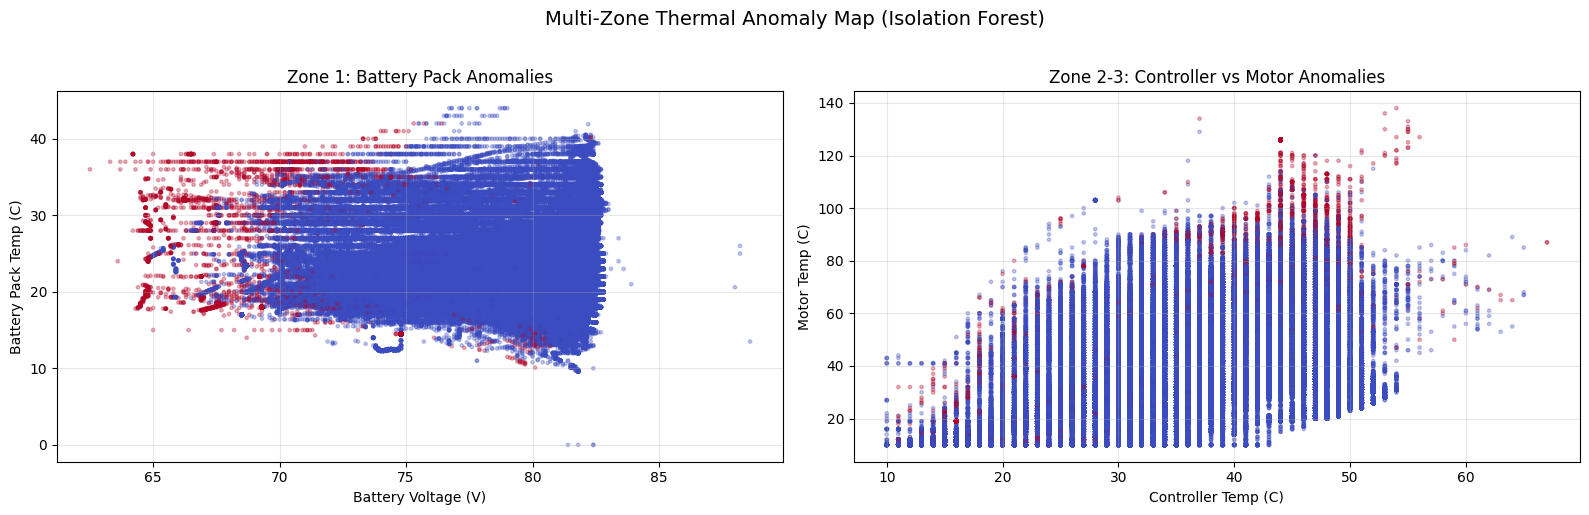

In [16]:
# Multi-Zone Anomaly Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Battery Temp vs Voltage (classic)
axes[0].scatter(therm_sample['vbv'], therm_sample['vbt'],
                c=therm_sample['anomaly'], cmap='coolwarm', alpha=0.3, s=6)
axes[0].set_xlabel("Battery Voltage (V)")
axes[0].set_ylabel("Battery Pack Temp (C)")
axes[0].set_title("Zone 1: Battery Pack Anomalies")
axes[0].grid(alpha=0.3)

# Plot 2: Controller vs Motor Temp (NEW multi-zone view)
if 'vct' in iso_features and 'vmt' in iso_features:
    axes[1].scatter(therm_sample['vct'], therm_sample['vmt'],
                    c=therm_sample['anomaly'], cmap='coolwarm', alpha=0.3, s=6)
    axes[1].set_xlabel("Controller Temp (C)")
    axes[1].set_ylabel("Motor Temp (C)")
    axes[1].set_title("Zone 2-3: Controller vs Motor Anomalies")
    axes[1].grid(alpha=0.3)
elif 'vct' in iso_features:
    axes[1].scatter(therm_sample['vbv'], therm_sample['vct'],
                    c=therm_sample['anomaly'], cmap='coolwarm', alpha=0.3, s=6)
    axes[1].set_xlabel("Battery Voltage (V)")
    axes[1].set_ylabel("Controller Temp (C)")
    axes[1].set_title("Zone 2: Controller Anomalies")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Single-zone only\n(vct/vmt not available)',
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title("Multi-Zone Not Available")

plt.suptitle("Multi-Zone Thermal Anomaly Map (Isolation Forest)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

pickle.dump(iso_forest, open(os.path.join(MDL_DIR, 'thermal_isoforest_multizone_v32.pkl'), 'wb'))

## 9. Thermal Model 5 (Champion): Random Forest Classifier
**Paper Ref:** Section 3.3.2 — *"granular ML classifiers designed to detect nascent thermal anomalies"*

An ensemble of 200 decision trees using the balanced Alert Log labels. Each tree votes independently on whether an alert represents a critical battery event or a benign driving infraction. The ensemble's majority vote is far more robust than any single decision boundary.

Random Forest (200 trees) Results:
  F1: 0.9971 | Accuracy: 0.9971 | Precision: 0.9971 | Recall: 0.9971

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      1032
    Critical       1.00      1.00      1.00      1031

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



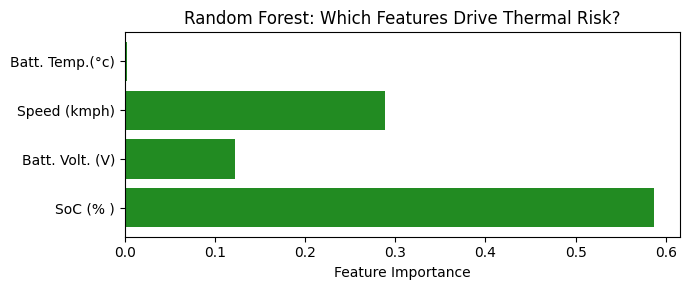

In [17]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5,
                                  random_state=SEED, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_s, y_train)

rf_pred = rf_model.predict(X_test_s)
f1_rf = f1_score(y_test, rf_pred, average='weighted')
acc_rf = accuracy_score(y_test, rf_pred)
prec_rf = precision_score(y_test, rf_pred, average='weighted')
rec_rf = recall_score(y_test, rf_pred, average='weighted')

print(f"Random Forest (200 trees) Results:")
print(f"  F1: {f1_rf:.4f} | Accuracy: {acc_rf:.4f} | Precision: {prec_rf:.4f} | Recall: {rec_rf:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=['Benign', 'Critical']))

# Feature Importance
importances = rf_model.feature_importances_
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(feat_cols, importances, color='forestgreen')
ax.set_title("Random Forest: Which Features Drive Thermal Risk?")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

pickle.dump(rf_model, open(os.path.join(MDL_DIR, 'thermal_rf_champion_v32.pkl'), 'wb'))

## 10. Confusion Matrices (Visual Proof of Model Progression)

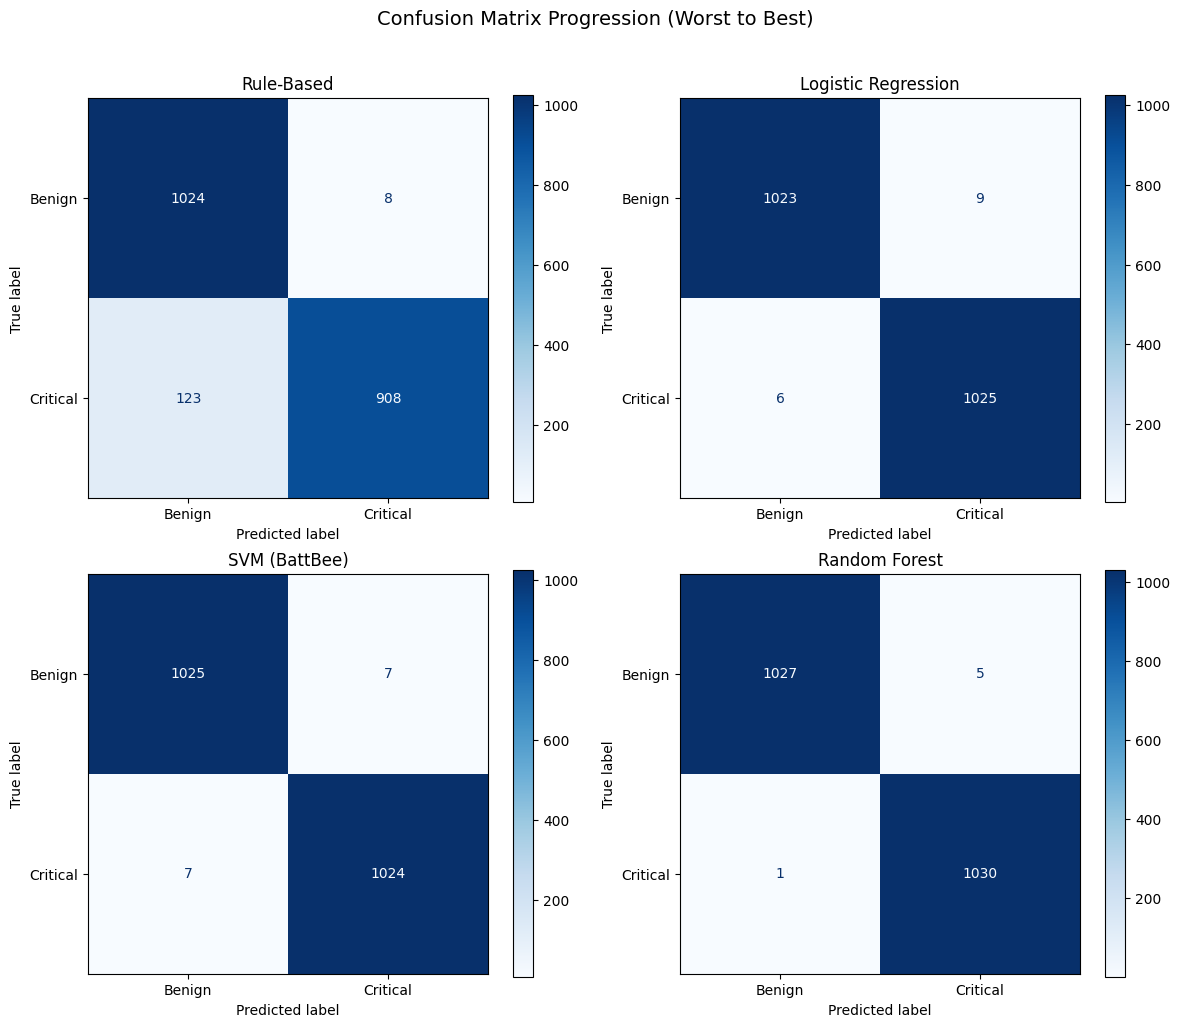

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_names = ['Rule-Based', 'Logistic Regression', 'SVM (BattBee)', 'Random Forest']
preds_list = [rule_pred, lr_pred, svm_pred, rf_pred]

for ax, name, preds in zip(axes.flatten(), model_names, preds_list):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Critical']).plot(ax=ax, cmap='Blues')
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrix Progression (Worst to Best)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Thermal Management: Final Comparison Table

In [19]:
thermal_results = pd.DataFrame([
    {'Rank': 5, 'Model': 'Rule-Based Threshold', 'Type': 'Manual (No ML)',
     'Paper Ref': 'Sec 3.3', 'F1': f"{f1_rule:.4f}",
     'Precision': f"{prec_rule:.4f}", 'Recall': f"{rec_rule:.4f}", 'Accuracy': f"{acc_rule:.4f}"},
    {'Rank': 4, 'Model': 'Logistic Regression', 'Type': 'Linear Classifier',
     'Paper Ref': 'Sec 5.1', 'F1': f"{f1_lr:.4f}",
     'Precision': f"{prec_lr:.4f}", 'Recall': f"{rec_lr:.4f}", 'Accuracy': f"{acc_lr:.4f}"},
    {'Rank': 3, 'Model': 'SVM Classifier (BattBee)', 'Type': 'Kernel SVM',
     'Paper Ref': 'BattBee [13]', 'F1': f"{f1_svm:.4f}",
     'Precision': f"{prec_svm:.4f}", 'Recall': f"{rec_svm:.4f}", 'Accuracy': f"{acc_svm:.4f}"},
    {'Rank': 2, 'Model': 'Isolation Forest (Multi-Zone)', 'Type': 'Unsupervised',
     'Paper Ref': 'Sec 3.3.2', 'F1': 'N/A (Unsupervised)',
     'Precision': 'N/A', 'Recall': 'N/A', 'Accuracy': f"{anom_rate:.2f}% anomaly rate"},
    {'Rank': 1, 'Model': 'Random Forest (200 trees)', 'Type': 'Ensemble',
     'Paper Ref': 'Sec 3.3.2', 'F1': f"{f1_rf:.4f}",
     'Precision': f"{prec_rf:.4f}", 'Recall': f"{rec_rf:.4f}", 'Accuracy': f"{acc_rf:.4f}"},
])

pd.set_option('display.max_colwidth', None)
print("\n" + "=" * 70)
print("  THERMAL MANAGEMENT: MODEL COMPARISON (V3.2 — Balanced Dataset)")
print("=" * 70)
display(thermal_results.sort_values('Rank', ascending=False))


  THERMAL MANAGEMENT: MODEL COMPARISON (V3.2 — Balanced Dataset)


,Rank,Model,Type,Paper Ref,F1,Precision,Recall,Accuracy
0,5,Rule-Based Threshold,Manual (No ML),Sec 3.3,0.9363,0.9420,0.9365,0.9365
1,4,Logistic Regression,Linear Classifier,Sec 5.1,0.9927,0.9927,0.9927,0.9927
2,3,SVM Classifier (BattBee),Kernel SVM,BattBee [13],0.9932,0.9932,0.9932,0.9932
3,2,Isolation Forest (Multi-Zone),Unsupervised,Sec 3.3.2,N/A (Unsupervised),N/A,N/A,2.00% anomaly rate
4,1,Random Forest (200 trees),Ensemble,Sec 3.3.2,0.9971,0.9971,0.9971,0.9971


In [20]:
print("=" * 60)
print("V3.2 THERMAL MANAGEMENT SUMMARY")
print("=" * 60)
print(f"\nTotal thermal models trained: 5")
print(f"  - Supervised models: 4 (Rule-Based, LogReg, SVM, RF)")
print(f"  - Unsupervised model: 1 (Isolation Forest Multi-Zone)")
print(f"\nDataset: {len(balanced_df)} balanced alert records (50/50 split)")
print(f"Multi-zone thermal features: {iso_features}")
print(f"\nAll models saved to: {MDL_DIR}")
print(f"\nPeak RAM: ", end="")
check_ram()

V3.2 THERMAL MANAGEMENT SUMMARY

Total thermal models trained: 5
  - Supervised models: 4 (Rule-Based, LogReg, SVM, RF)
  - Unsupervised model: 1 (Isolation Forest Multi-Zone)

Dataset: 10314 balanced alert records (50/50 split)
Multi-zone thermal features: ['vbt', 'vbv', 'vbc', 'soc', 'vct', 'vmt']

All models saved to: /content/drive/MyDrive/FYP_Battery_Project/Models_v3_2_Thermal

Peak RAM: RAM Used: 0.86 GB
